# Semana 8 — Projeto Prático de Data Warehouse e Modelagem Dimensional

Mini Data Warehouse de e-commerce usando o dataset Olist.

## Objetivos

- Diferenciar OLTP e OLAP
- Executar ETL com Pandas
- Criar dimensões e tabela fato
- Identificar PK, FK e Surrogate Key
- Criar Star Schema
- Consultar o modelo com SQL
- Interpretar métricas de BI

## Arquivos necessários

Baixe no Kaggle o dataset Brazilian E-Commerce Public Dataset by Olist e coloque na pasta do notebook:

- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_products_dataset.csv
- product_category_name_translation.csv

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)

# 1. Cenário de negócio

O diretor quer responder:

1. Qual foi o faturamento total?
2. Quais estados mais faturaram?
3. Quais categorias mais venderam?
4. Qual foi o ticket médio?
5. Como o faturamento evoluiu ao longo do tempo?

# 2. Extract — carregando fontes OLTP

In [4]:
pedidos = pd.read_csv('../Dataset/olist_orders_dataset.csv')
itens = pd.read_csv('../Dataset/olist_order_items_dataset.csv')
clientes = pd.read_csv('../Dataset/olist_customers_dataset.csv')
produtos = pd.read_csv('../Dataset/olist_products_dataset.csv')
traducao_categoria = pd.read_csv('../Dataset/product_category_name_translation.csv')

print('orders:', pedidos.shape)
print('items:', itens.shape)
print('customers:', clientes.shape)
print('products:', produtos.shape)
print('category_translation:', traducao_categoria.shape)

orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
category_translation: (71, 2)


## Exercício 1 🟢 Fácil — OLTP

Responda:

1. Por que essas tabelas podem ser consideradas fontes OLTP?

R: Porque são tabelas de banco de dados transacionais onde foram registradas as operações e dados de vendas da empresa.

2. Qual tabela registra o pedido?

R: A tabela "pedidos" que foi carregada do arquivo "olist_orders_dataset.csv"

3. Qual tabela registra os itens de cada pedido?

R: A tabela "itens" que foi carregada do arquivo "olist_order_items_dataset.csv"

4. Qual tabela descreve os clientes?

R: A tabela "clientes" que foi carregada do arquivo "olist_customers_dataset.csv"

5. Qual tabela descreve os produtos?

R: A tabela "produtos" que foi carregada do arquivo "olist_products_dataset.csv"

# 3. Análise exploratória inicial

In [5]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [15]:
produtos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [26]:
traducao_categoria.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## Exercício 2 🟢 Fácil — Explorando os dados

Use `.info()`, `.shape` e `.isnull().sum()` para investigar as tabelas.

In [81]:
# Investigue a tabela orders
pedidos.info()
pedidos.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
pedidos['order_status'].nunique()

8

In [76]:
print(pedidos['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [77]:
#pedidos[pedidos['order_approved_at'].isnull()]['order_status'].value_counts()

#pedidos[pedidos['order_delivered_carrier_date'].isnull()]['order_status'].value_counts()

pedidos[pedidos['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [ ]:
# Investigue a tabela items
itens.info()
itens.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [7]:
itens.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [ ]:
# Investigue a tabela customers
clientes.info()
clientes.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [84]:
clientes.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [ ]:
# Investigue a tabela products
produtos.info()
produtos.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [78]:
produtos.nunique()

product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

# 4. Transform — tratamento dos dados

Transformações comuns: converter tipos, remover duplicidades, tratar nulos, padronizar nomes e criar colunas derivadas.

In [7]:
pedidos_limpo = pedidos.copy()
pedidos_limpo['order_purchase_timestamp'] = pd.to_datetime(pedidos_limpo['order_purchase_timestamp'])
pedidos_limpo['order_approved_at'] = pd.to_datetime(pedidos_limpo['order_approved_at'],)
pedidos_limpo['order_delivered_customer_date'] = pd.to_datetime(pedidos_limpo['order_delivered_customer_date'])
pedidos_limpo['order_estimated_delivery_date'] = pd.to_datetime(pedidos_limpo['order_estimated_delivery_date'])
pedidos_limpo['order_delivered_carrier_date'] = pd.to_datetime(pedidos_limpo['order_delivered_carrier_date'])

pedidos_limpo[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_delivered_carrier_date']].head()


,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_delivered_carrier_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,2017-10-04 19:55:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,2018-07-26 14:31:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,2018-08-08 13:50:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15,2017-11-22 13:39:59
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26,2018-02-14 19:46:34


In [8]:
pedidos_limpo['order_status'] = pedidos_limpo['order_status'].astype('category')

clientes_limpo = clientes.copy()
clientes_limpo['customer_state'] = clientes_limpo['customer_state'].astype('category')

produtos_limpo = produtos.copy()
produtos_limpo['product_category_name'] = produtos_limpo['product_category_name'].astype('category')

## Exercício 3 🟢 Fácil — Criando atributos de tempo

Crie as colunas `ano`, `mes`, `dia`, `trimestre` e `ano_mes` a partir de `order_purchase_timestamp`.

In [9]:
#Crie as colunas `ano`, `mes`, `dia`, `trimestre` e `ano_mes` a partir de `order_purchase_timestamp`.
pedidos_limpo['data'] = pedidos_limpo['order_purchase_timestamp'].dt.date #cria a coluna data apenas com a data, sem o horário
pedidos_limpo['ano'] = pedidos_limpo['order_purchase_timestamp'].dt.year
pedidos_limpo['mes'] = pedidos_limpo['order_purchase_timestamp'].dt.month
pedidos_limpo['dia'] = pedidos_limpo['order_purchase_timestamp'].dt.day
pedidos_limpo['trimestre'] = pedidos_limpo['order_purchase_timestamp'].dt.quarter
pedidos_limpo['ano_mes'] = pedidos_limpo['order_purchase_timestamp'].dt.to_period('M').astype(str)

pedidos_limpo[['data','ano', 'mes', 'dia', 'trimestre', 'ano_mes']].head()


,data,ano,mes,dia,trimestre,ano_mes
0,2017-10-02,2017,10,2,4,2017-10
1,2018-07-24,2018,7,24,3,2018-07
2,2018-08-08,2018,8,8,3,2018-08
3,2017-11-18,2017,11,18,4,2017-11
4,2018-02-13,2018,2,13,1,2018-02


## Exercício 4 🟢 Fácil — Remoção de duplicidades

Verifique se existem duplicidades nas tabelas principais e remova-as.

In [10]:
# SUA RESPOSTA AQUI
total_linhas = len(pedidos_limpo)
linhas_unicas = len(pedidos_limpo.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('\nMostrando o impacto da remoção dos duplicados em pedidos_limpo:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')

total_linhas = len(produtos_limpo)
linhas_unicas = len(produtos_limpo.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('\nMostrando o impacto da remoção dos duplicados em produtos_limpo:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')

total_linhas = len(clientes_limpo)
linhas_unicas = len(clientes_limpo.drop_duplicates())
duplicadas = total_linhas - linhas_unicas

print('\nMostrando o impacto da remoção dos duplicados em clientes_limpo:')    
print(f'Total de linhas: {total_linhas:,}')
print(f'Linhas únicas: {linhas_unicas:,}')
print(f'Linhas duplicadas: {duplicadas:,}')
print(f'Percentual removido: {(duplicadas/total_linhas)*100:.2f}%')


Mostrando o impacto da remoção dos duplicados em pedidos_limpo:
Total de linhas: 99,441
Linhas únicas: 99,441
Linhas duplicadas: 0
Percentual removido: 0.00%

Mostrando o impacto da remoção dos duplicados em produtos_limpo:
Total de linhas: 32,951
Linhas únicas: 32,951
Linhas duplicadas: 0
Percentual removido: 0.00%

Mostrando o impacto da remoção dos duplicados em clientes_limpo:
Total de linhas: 99,441
Linhas únicas: 99,441
Linhas duplicadas: 0
Percentual removido: 0.00%


## Exercício 5 🟡 Médio — Filtro de pedidos válidos

Considere apenas pedidos com status `delivered` e crie `produtos_entregue`.

In [11]:
# SUA RESPOSTA AQUI
# Considere apenas pedidos com status `delivered` e crie `produtos_entregue`.
produtos_entregue = pedidos_limpo[pedidos_limpo['order_status'] == 'delivered']

print(f'Número de pedidos entregues: {len(produtos_entregue):,}')



Número de pedidos entregues: 96,478


# 5. Modelagem dimensional

Modelo esperado:

```text
dim_cliente
     |
dim_produto -- fato_vendas -- dim_tempo
```

A tabela fato guarda eventos mensuráveis. As dimensões guardam contexto.

# 6. Criando a dimensão cliente

In [12]:
dim_cliente = clientes_limpo[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']].drop_duplicates().copy()
dim_cliente = dim_cliente.reset_index(drop=True)
dim_cliente['cliente_sk'] = dim_cliente.index + 1
dim_cliente = dim_cliente[['cliente_sk', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state']]
dim_cliente.head()

,cliente_sk,customer_id,customer_unique_id,customer_city,customer_state
0,1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP
1,2,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP
2,3,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP
3,4,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP
4,5,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP


## Exercício 6 🟡 Médio — PK, SK e chave natural

1. Qual coluna é a Surrogate Key da dimensão cliente?

R: a coluna "cliente_sk"

2. Qual coluna veio do sistema de origem?

R: 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state'

3. Por que não usar CPF, e-mail ou código da origem como PK física do DW?

R: Porque além de ser dados "sensíveis" do cliente, são números que podem dificultar os relacionamentos no DW.

# 7. Criando a dimensão produto

In [13]:
dim_produto = produtos_limpo[['product_id', 'product_category_name']].drop_duplicates().copy()
dim_produto = dim_produto.merge(traducao_categoria, on='product_category_name', how='left')
dim_produto['product_category_name_english'] = dim_produto['product_category_name_english'].fillna('unknown')
dim_produto = dim_produto.reset_index(drop=True)
dim_produto['produto_sk'] = dim_produto.index + 1
dim_produto = dim_produto[['produto_sk', 'product_id', 'product_category_name', 'product_category_name_english']]
dim_produto.head()

,produto_sk,product_id,product_category_name,product_category_name_english
0,1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,2,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,4,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## Exercício 7 🟡 Médio — Star Schema vs Snowflake

1. Esse modelo se parece mais com Star Schema ou Snowflake?

R: Com star schema

2. Como ficaria se categoria fosse uma tabela separada?

R: então seria uma tabela dimensão relacionada a tabela produto, indo para estrutura Snowflake

3. Qual opção costuma ser mais simples para Power BI?

R: Star Schema

# 8. Criando a dimensão tempo

In [14]:
produtos_entregue['order_purchase_timestamp'].isnull().sum()

np.int64(0)

In [15]:
#verifica se tem duplicidade de data e copia a tabela para criar a dimensão tempo

dim_tempo = produtos_entregue[['order_purchase_timestamp']].drop_duplicates().copy()

### Crie as colunas necessárias para a dimensão tempo
dim_tempo['data'] = dim_tempo['order_purchase_timestamp'].dt.date #cria a coluna data apenas com a data, sem o horário
dim_tempo['ano'] = dim_tempo['order_purchase_timestamp'].dt.year #cria a coluna ano apenas com o ano da data
dim_tempo['mes'] = dim_tempo['order_purchase_timestamp'].dt.month #cria a coluna mes apenas com o mês da data
dim_tempo['dia'] = dim_tempo['order_purchase_timestamp'].dt.day #cria a coluna dia apenas com o dia da data
dim_tempo['trimestre'] = dim_tempo['order_purchase_timestamp'].dt.quarter #cria a coluna trimestre apenas com o trimestre da data


dim_tempo['ano_mes'] = dim_tempo['order_purchase_timestamp'].dt.to_period('M').astype(str) #cria a coluna ano_mes apenas com o ano e o mês da data, no formato "YYYY-MM"
dim_tempo = dim_tempo.drop_duplicates('data').reset_index(drop=True) #remove as linhas duplicadas com base na coluna data e reseta o índice
dim_tempo['tempo_sk'] = dim_tempo.index + 1 #cria a coluna tempo_sk com os valores sequenciais
dim_tempo = dim_tempo[['tempo_sk', 'data', 'ano', 'mes', 'dia', 'trimestre', 'ano_mes']] #reordena as colunas da dimensão tempo
dim_tempo.head() #exibe as primeiras linhas da dimensão tempo

,tempo_sk,data,ano,mes,dia,trimestre,ano_mes
0,1,2017-10-02,2017,10,2,4,2017-10
1,2,2018-07-24,2018,7,24,3,2018-07
2,3,2018-08-08,2018,8,8,3,2018-08
3,4,2017-11-18,2017,11,18,4,2017-11
4,5,2018-02-13,2018,2,13,1,2018-02


## Exercício 8 🟡 Médio — Dimensão tempo

1. Por que uma dimensão tempo é útil em BI?

R: Porque é possível fazer consultas baseadas em tempo.

2. Que análises ela permite?

R: Volume de vendas por dia, por dia da semana, mês, ano, trimestre e ainda por intervalo de tempo.

3. Qual coluna é a SK da dimensão tempo?

R: tempo_sk

# 9. Criando a tabela fato

Evento: um item vendido dentro de um pedido.

Granularidade: uma linha por item vendido em um pedido.

In [16]:
fato_vendas = itens[['order_id', 'order_item_id', 'product_id', 'price', 'freight_value']].copy()
fato_vendas = fato_vendas.merge(produtos_entregue[['order_id', 'customer_id', 'order_purchase_timestamp', 'data']], on='order_id', how='inner')
#fato_vendas.head()
print(f'Número de linhas no produtos_entregue: {len(produtos_entregue):,}')
print(f'Número de linhas no itens: {len(itens):,}')
print(f'Número de linhas no fato vendas: {len(fato_vendas):,}')


Número de linhas no produtos_entregue: 96,478
Número de linhas no itens: 112,650
Número de linhas no fato vendas: 110,197


In [17]:
itens_por_pedido = (
    fato_vendas
    .groupby('order_id')
    .size()
)

itens_por_pedido.value_counts().sort_index()

1     86843
2      7392
3      1306
4       495
5       193
6       191
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

## Exercício 9 🟡 Médio — Relacionando fato e dimensões

Complete a construção da `fato_vendas` trazendo `cliente_sk`, `produto_sk` e `tempo_sk`.

In [36]:
# SUA RESPOSTA AQUI
# COM MERGE

"""
fato_vendas = fato_vendas.merge(
    dim_cliente[['cliente_sk', 'customer_id']],
    on='customer_id',
    how='left'
)

fato_vendas = fato_vendas.merge(
    dim_produto[['produto_sk', 'product_id']],
    on='product_id',
    how='left'
)

fato_vendas = fato_vendas.merge(
    dim_tempo[['tempo_sk', 'data']],
    on='data',
    how='left'
)
"""


"\nfato_vendas = fato_vendas.merge(\n    dim_cliente[['cliente_sk', 'customer_id']],\n    on='customer_id',\n    how='left'\n)\n\nfato_vendas = fato_vendas.merge(\n    dim_produto[['produto_sk', 'product_id']],\n    on='product_id',\n    how='left'\n)\n\nfato_vendas = fato_vendas.merge(\n    dim_tempo[['tempo_sk', 'data']],\n    on='data',\n    how='left'\n)\n"

In [18]:
# COM MAP CRIANDO UM DICIONÁRIO

cliente_map = dim_cliente.set_index('customer_id')['cliente_sk']
produto_map = dim_produto.set_index('product_id')['produto_sk']
tempo_map = dim_tempo.set_index('data')['tempo_sk']

fato_vendas['cliente_sk'] = fato_vendas['customer_id'].map(cliente_map)
fato_vendas['produto_sk'] = fato_vendas['product_id'].map(produto_map)
fato_vendas['tempo_sk'] = fato_vendas['data'].map(tempo_map)

fato_vendas = fato_vendas[
    [
        'cliente_sk',
        'produto_sk',
        'tempo_sk',
        'order_id',
        'order_item_id',
        'price',
        'freight_value'
    ]
]

fato_vendas.head()

,cliente_sk,produto_sk,tempo_sk,order_id,order_item_id,price,freight_value
0,65558,25866,64,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
1,34266,27231,125,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
2,34956,22625,222,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
3,51764,15404,3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
4,7603,8863,512,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


## Exercício 10 🟡 Médio — Métricas da fato

Crie `valor_produto`, `valor_frete` e `valor_total`.

In [19]:
# SUA RESPOSTA AQUI
fato_vendas.rename(columns={'price': 'valor_produto', 'freight_value': 'valor_frete'}, inplace=True)
fato_vendas['valor_total'] = (fato_vendas['valor_produto'] + fato_vendas['valor_frete'])

fato_vendas.head()

,cliente_sk,produto_sk,tempo_sk,order_id,order_item_id,valor_produto,valor_frete,valor_total
0,65558,25866,64,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,34266,27231,125,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,34956,22625,222,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,51764,15404,3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,7603,8863,512,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


## Exercício 11 🔴 Difícil — Fato final

Deixe a fato com: `order_id`, `order_item_id`, `cliente_sk`, `produto_sk`, `tempo_sk`, `valor_produto`, `valor_frete`, `valor_total`.

Depois, crie `venda_sk`.

In [20]:
# SUA RESPOSTA AQUI
fato_vendas['venda_sk'] = fato_vendas.index +1

fato_vendas_final = fato_vendas[
    [
        'venda_sk',
        'cliente_sk',
        'produto_sk',
        'tempo_sk',
        'order_id',
        'order_item_id',
        'valor_produto',
        'valor_frete',
        'valor_total'
    ]
]

fato_vendas_final.head()

,venda_sk,cliente_sk,produto_sk,tempo_sk,order_id,order_item_id,valor_produto,valor_frete,valor_total
0,1,65558,25866,64,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19
1,2,34266,27231,125,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83
2,3,34956,22625,222,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87
3,4,51764,15404,3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,25.78
4,5,7603,8863,512,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,218.04


# 10. Validando o Star Schema

## Exercício 12 🔴 Difícil — Documentação do modelo

| Tabela | Tipo | PK | FK | Descrição |
|---|---|---|---|---|
| dim_cliente |  |  |  |  |
| dim_produto |  |  |  |  |
| dim_tempo |  |  |  |  |
| fato_vendas |  |  |  |  |

# 11. SQL Analítico com DuckDB

In [21]:
con = duckdb.connect()
con.register('dim_cliente', dim_cliente) # registra a dimensão cliente no banco de dados
con.register('dim_produto', dim_produto) # registra a dimensão produto no banco de dados
con.register('dim_tempo', dim_tempo) # registra a dimensão tempo no banco de dados
con.register('fato_vendas', fato_vendas_final) # registra a tabela fato vendas no banco de dados

## Consulta exemplo — Faturamento total

In [22]:
resultado = con.sql("""
SELECT SUM(valor_total) AS faturamento_total
FROM fato_vendas
""").df() # consulta para calcular o faturamento total da loja, somando a coluna valor_total da tabela fato_vendas

print(f'R$ {resultado["faturamento_total"][0]:,.2f}')

R$ 15,419,773.75


## Exercício 13 🟡 Médio — Faturamento por estado

In [ ]:
con.sql("""
-- SUA CONSULTA SQL AQUI
""").df() 

## Exercício 14 🟡 Médio — Top 10 categorias

In [ ]:
con.sql("""
-- SUA CONSULTA SQL AQUI
""").df() 

## Exercício 15 🔴 Difícil — Ticket médio por estado

In [ ]:
con.sql("""
-- SUA CONSULTA SQL AQUI
""").df()

## Exercício 16 🔴 Difícil — Evolução mensal de faturamento

In [ ]:
con.sql("""
-- SUA CONSULTA SQL AQUI
""").df()

# 12. Visualização simples

In [71]:
faturamento_mensal = con.sql("""
SELECT t.ano_mes, SUM(f.valor_total) AS faturamento_total
FROM fato_vendas f
JOIN dim_tempo t ON f.tempo_sk = t.tempo_sk
GROUP BY t.ano_mes
ORDER BY t.ano_mes
""").df()
faturamento_mensal.head()

,ano_mes,faturamento_total
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32


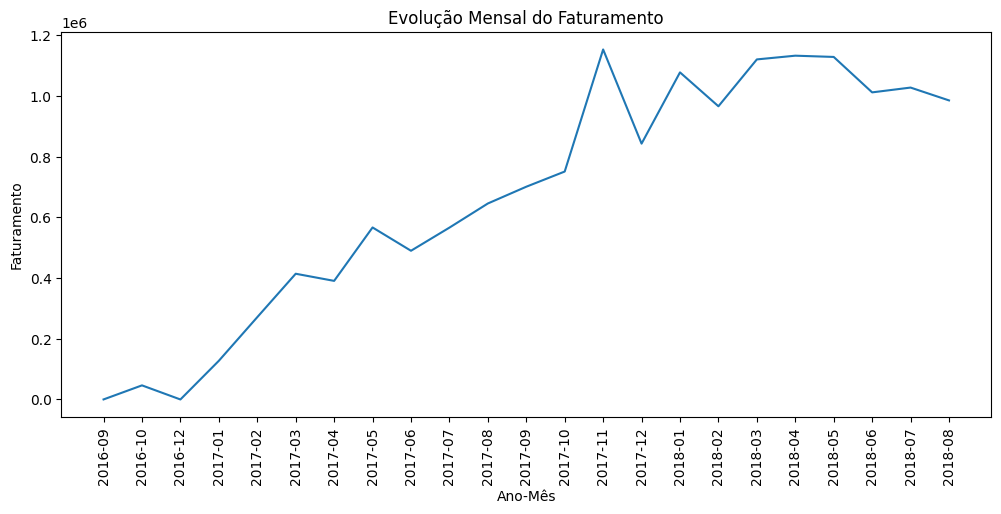

In [72]:
plt.figure(figsize=(12,5))
plt.plot(faturamento_mensal['ano_mes'], faturamento_mensal['faturamento_total'])
plt.xticks(rotation=90)
plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Ano-Mês')
plt.ylabel('Faturamento')
plt.show()

## Exercício 17 🔴 Difícil — Visualização

Crie um gráfico de barras com o faturamento por estado.

In [ ]:
# SUA RESPOSTA AQUI

# 13. Snowflake Schema — desafio conceitual

No modelo atual, `dim_produto` possui categoria dentro da própria dimensão.

Em Snowflake, poderíamos separar `dim_produto` e `dim_categoria`.

## Exercício 18 🔴 Difícil

1. Qual vantagem do Snowflake nesse caso?
2. Qual desvantagem?
3. Para Power BI, você escolheria Star ou Snowflake? Justifique.

# 14. Desafio Final — Caso Executivo

O diretor pediu uma análise com:

1. Faturamento total
2. Top 5 estados por faturamento
3. Top 10 categorias
4. Ticket médio geral
5. Evolução mensal do faturamento
6. Explicação do modelo dimensional usado
7. Justificativa de por que a solução é OLAP

## Entrega

- Notebook preenchido
- Print ou desenho do Star Schema
- Resposta executiva com 5 a 10 linhas